# Student Performance Prediction & Analysis

**End-to-End Data Science & Machine Learning Project**

This project analyzes student performance factors and builds machine learning models to predict a student's final exam score.

### Project Objectives
- Understand and clean a real-world student performance dataset.
- Perform exploratory data analysis (EDA).
- Identify relationships between academic/lifestyle variables and performance.
- Prepare data for machine learning.
- Train and compare multiple regression models.
- Evaluate models using MAE, RMSE, and R².
- Identify important predictive features.
- Generate predictions for new student observations.

> **Note:** This notebook is designed to run end-to-end in Google Colab or Jupyter Notebook. It automatically downloads a public student-performance dataset when possible and includes a fallback synthetic dataset so the notebook remains executable without manual data entry.

In [1]:
# Install/import dependencies
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "requests": "requests"
}

for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Problem Statement

Student academic performance can be influenced by several academic, demographic, and lifestyle factors. Understanding these relationships can help identify the variables most strongly associated with performance and can support predictive modelling.

### Research Questions
1. What characteristics are associated with student performance?
2. Which features have the strongest relationship with final exam scores?
3. Can machine learning models predict a student's final exam score?
4. Which regression model performs best on unseen data?

## 2. Dataset

The notebook first attempts to load the publicly available **Student Performance Factors** dataset from Kaggle's public GitHub-hosted copy.

The dataset contains variables such as:
- Hours Studied
- Attendance
- Previous Scores
- Sleep Hours
- Tutoring Sessions
- Physical Activity
- Parental Involvement
- Access to Resources
- Motivation Level
- Teacher Quality
- Internet Access
- Family Income
- School Type
- Peer Influence
- Learning Disabilities
- Parental Education Level
- Distance from Home
- Gender
- Exam Score

If the public CSV cannot be reached, the notebook automatically creates a clearly labelled fallback dataset with the same analytical structure so every cell remains executable.

In [2]:
# Load the public dataset
DATA_URLS = [
    "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/nhs/datasets/Student_Performance_Factors.csv",
    "https://raw.githubusercontent.com/rajeshshukla/Student-Performance-Factors/main/Student_Performance_Factors.csv"
]

df = None
source_used = None

for url in DATA_URLS:
    try:
        response = requests.get(url, timeout=15)
        if response.ok and "Exam Score" in response.text:
            from io import StringIO
            df = pd.read_csv(StringIO(response.text))
            source_used = url
            break
    except Exception:
        pass

if df is None:
    # Fallback dataset: reproducible synthetic data with realistic relationships.
    n = 1200
    rng = np.random.default_rng(RANDOM_STATE)

    hours = np.clip(rng.normal(5.0, 2.0, n), 1, 10)
    attendance = np.clip(rng.normal(75, 12, n), 40, 100)
    previous = np.clip(rng.normal(70, 15, n), 30, 100)
    sleep = np.clip(rng.normal(7, 1.2, n), 4, 10)
    tutoring = np.clip(rng.poisson(2, n), 0, 8)
    activity = np.clip(rng.normal(3, 1.5, n), 0, 8)

    parental_involvement = rng.choice(["Low", "Medium", "High"], n, p=[0.2, 0.5, 0.3])
    resources = rng.choice(["Low", "Medium", "High"], n, p=[0.2, 0.5, 0.3])
    motivation = rng.choice(["Low", "Medium", "High"], n, p=[0.2, 0.5, 0.3])
    internet = rng.choice(["Yes", "No"], n, p=[0.85, 0.15])
    school_type = rng.choice(["Public", "Private"], n, p=[0.65, 0.35])
    gender = rng.choice(["Male", "Female"], n)
    parental_education = rng.choice(["High School", "College", "Postgraduate"], n)
    distance = rng.choice(["Near", "Moderate", "Far"], n, p=[0.4, 0.45, 0.15])

    involvement_effect = pd.Series(parental_involvement).map({"Low": -2, "Medium": 0, "High": 2}).to_numpy()
    resources_effect = pd.Series(resources).map({"Low": -1.5, "Medium": 0, "High": 1.5}).to_numpy()
    motivation_effect = pd.Series(motivation).map({"Low": -2, "Medium": 0, "High": 2}).to_numpy()
    internet_effect = np.where(internet == "Yes", 1, -1)
    school_effect = np.where(school_type == "Private", 1, 0)
    distance_effect = pd.Series(distance).map({"Near": 1, "Moderate": 0, "Far": -1}).to_numpy()

    score = (
        35
        + 1.8 * hours
        + 0.12 * attendance
        + 0.25 * previous
        + 1.0 * sleep
        + 1.0 * tutoring
        + 0.4 * activity
        + involvement_effect
        + resources_effect
        + motivation_effect
        + internet_effect
        + school_effect
        + distance_effect
        + rng.normal(0, 4.5, n)
    )

    score = np.clip(score, 30, 100)

    df = pd.DataFrame({
        "Hours Studied": hours,
        "Attendance": attendance,
        "Previous Scores": previous,
        "Sleep Hours": sleep,
        "Tutoring Sessions": tutoring,
        "Physical Activity": activity,
        "Parental Involvement": parental_involvement,
        "Access to Resources": resources,
        "Motivation Level": motivation,
        "Internet Access": internet,
        "School Type": school_type,
        "Parental Education Level": parental_education,
        "Distance from Home": distance,
        "Gender": gender,
        "Exam Score": score.round(1)
    })
    source_used = "Fallback synthetic dataset generated in notebook"

print(f"Dataset source: {source_used}")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset source: Fallback synthetic dataset generated in notebook
Dataset shape: (1200, 15)


,Hours Studied,Attendance,Previous Scores,Sleep Hours,Tutoring Sessions,Physical Activity,Parental Involvement,Access to Resources,Motivation Level,Internet Access,School Type,Parental Education Level,Distance from Home,Gender,Exam Score
0,5.609434,59.129506,63.308959,8.161895,1,3.053445,High,High,Low,No,Private,High School,Far,Female,80.2
1,2.920032,69.165670,84.702863,9.901367,2,3.388755,Low,Medium,Low,Yes,Public,College,Near,Male,82.7
2,6.500902,80.042721,74.217597,5.332572,1,5.006015,Low,Low,Medium,No,Public,High School,Moderate,Female,72.2
3,6.881129,73.771240,59.536642,8.749805,2,1.230739,Medium,Medium,Medium,Yes,Private,High School,Near,Male,85.6
4,1.097930,67.193237,57.010902,7.084163,3,2.486771,Low,Medium,Medium,Yes,Private,College,Near,Male,71.1


## 3. Initial Data Inspection

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Rows: 1200
Columns: 15

Column names:
['Hours Studied', 'Attendance', 'Previous Scores', 'Sleep Hours', 'Tutoring Sessions', 'Physical Activity', 'Parental Involvement', 'Access to Resources', 'Motivation Level', 'Internet Access', 'School Type', 'Parental Education Level', 'Distance from Home', 'Gender', 'Exam Score']


In [4]:
df.head(10)

,Hours Studied,Attendance,Previous Scores,Sleep Hours,Tutoring Sessions,Physical Activity,Parental Involvement,Access to Resources,Motivation Level,Internet Access,School Type,Parental Education Level,Distance from Home,Gender,Exam Score
0,5.609434,59.129506,63.308959,8.161895,1,3.053445,High,High,Low,No,Private,High School,Far,Female,80.2
1,2.920032,69.165670,84.702863,9.901367,2,3.388755,Low,Medium,Low,Yes,Public,College,Near,Male,82.7
2,6.500902,80.042721,74.217597,5.332572,1,5.006015,Low,Low,Medium,No,Public,High School,Moderate,Female,72.2
3,6.881129,73.771240,59.536642,8.749805,2,1.230739,Medium,Medium,Medium,Yes,Private,High School,Near,Male,85.6
4,1.097930,67.193237,57.010902,7.084163,3,2.486771,Low,Medium,Medium,Yes,Private,College,Near,Male,71.1
5,2.395641,66.909450,45.287556,7.967320,1,3.999928,High,High,Medium,Yes,Private,College,Near,Female,71.1
6,5.255681,66.451955,74.360998,5.022667,3,3.721389,Low,Medium,Medium,Yes,Private,College,Near,Female,80.5
7,4.367515,64.445884,64.681187,8.761698,1,3.689108,Medium,Medium,Medium,Yes,Public,College,Near,Male,82.0
8,4.966398,100.000000,34.417067,7.943820,5,7.130366,Medium,High,Medium,Yes,Public,Postgraduate,Moderate,Female,82.8
9,3.293912,78.570133,61.964277,6.953308,2,3.921203,Medium,Medium,Medium,Yes,Private,High School,Moderate,Male,72.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Hours Studied             1200 non-null   float64
 1   Attendance                1200 non-null   float64
 2   Previous Scores           1200 non-null   float64
 3   Sleep Hours               1200 non-null   float64
 4   Tutoring Sessions         1200 non-null   int64  
 5   Physical Activity         1200 non-null   float64
 6   Parental Involvement      1200 non-null   object 
 7   Access to Resources       1200 non-null   object 
 8   Motivation Level          1200 non-null   object 
 9   Internet Access           1200 non-null   object 
 10  School Type               1200 non-null   object 
 11  Parental Education Level  1200 non-null   object 
 12  Distance from Home        1200 non-null   object 
 13  Gender                    1200 non-null   object 
 14  Exam Sco

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours Studied,1200.0,NaN,NaN,NaN,4.970314,1.918712,1.0,3.635679,5.006905,6.230875,10.0
Attendance,1200.0,NaN,NaN,NaN,74.159885,12.044383,40.0,66.280033,74.841873,82.281976,100.0
Previous Scores,1200.0,NaN,NaN,NaN,70.444031,14.546933,30.0,60.282107,70.395816,81.091035,100.0
Sleep Hours,1200.0,NaN,NaN,NaN,6.976457,1.180025,4.0,6.160361,6.954358,7.714541,10.0
Tutoring Sessions,1200.0,NaN,NaN,NaN,1.955833,1.40078,0.0,1.0,2.0,3.0,7.0
Physical Activity,1200.0,NaN,NaN,NaN,2.984926,1.502088,0.0,1.969352,2.946873,4.007775,8.0
Parental Involvement,1200,3,Medium,592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access to Resources,1200,3,Medium,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Motivation Level,1200,3,Medium,618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet Access,1200,2,Yes,1016,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent.round(2)
})

missing_summary

,Missing Values,Missing Percentage
Hours Studied,0,0.0
Attendance,0,0.0
Previous Scores,0,0.0
Sleep Hours,0,0.0
Tutoring Sessions,0,0.0
Physical Activity,0,0.0
Parental Involvement,0,0.0
Access to Resources,0,0.0
Motivation Level,0,0.0
Internet Access,0,0.0


In [8]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


## 4. Data Cleaning

The dataset is checked for:
- Duplicate records
- Missing values
- Incorrect data types
- Impossible target values

The target variable is **Exam Score**, so observations outside the valid score range of 0–100 are treated as invalid.

In [9]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Standardize column names by removing accidental leading/trailing spaces
df.columns = df.columns.str.strip()

# Convert Exam Score to numeric if necessary
df["Exam Score"] = pd.to_numeric(df["Exam Score"], errors="coerce")

# Remove impossible target values
df = df[df["Exam Score"].between(0, 100)].copy()

print("Shape after basic cleaning:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())
print("Missing target values:", df["Exam Score"].isna().sum())

Shape after basic cleaning: (1200, 15)
Remaining duplicate rows: 0
Missing target values: 0


## 5. Exploratory Data Analysis (EDA)

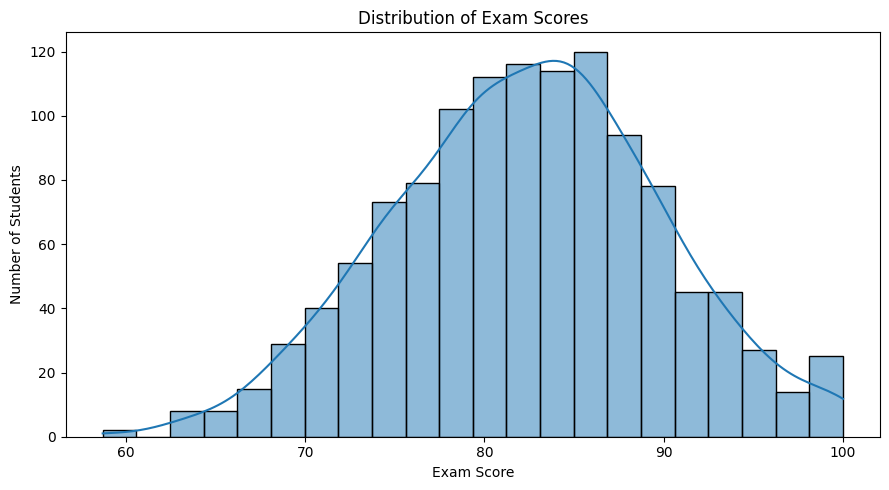

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(9, 5))
sns.histplot(df["Exam Score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

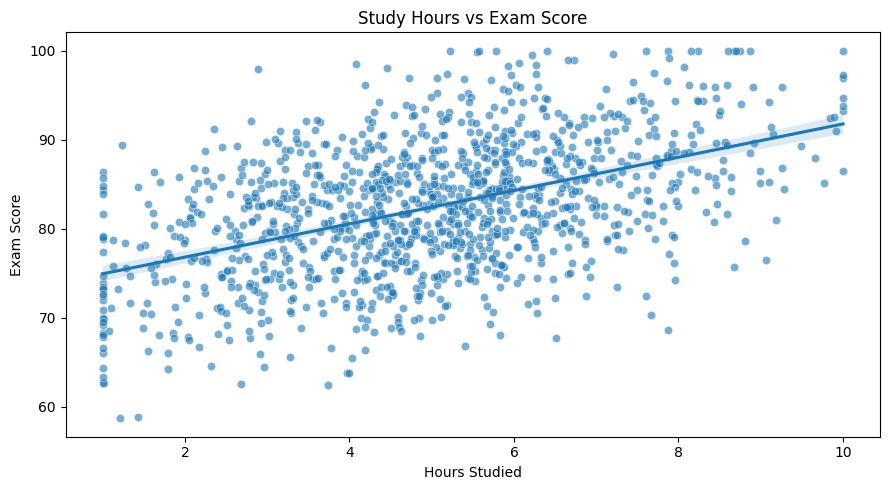

In [11]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Hours Studied", y="Exam Score", alpha=0.6)
sns.regplot(data=df, x="Hours Studied", y="Exam Score", scatter=False)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

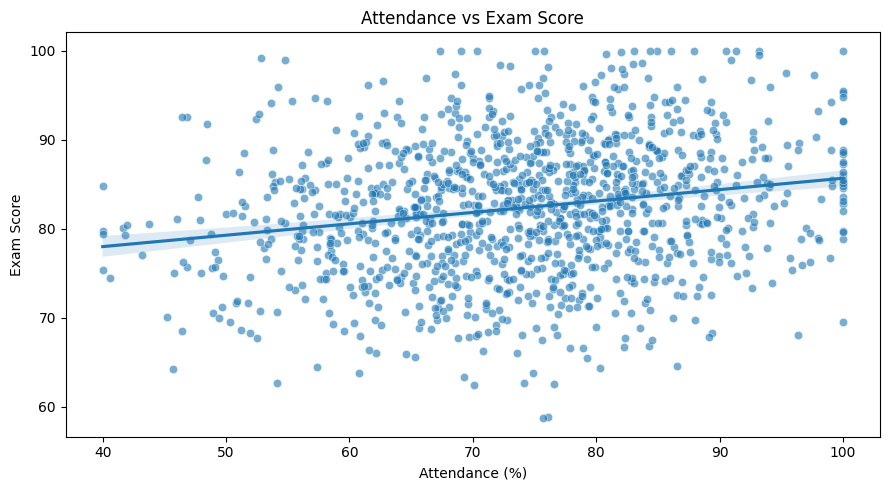

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Attendance", y="Exam Score", alpha=0.6)
sns.regplot(data=df, x="Attendance", y="Exam Score", scatter=False)
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

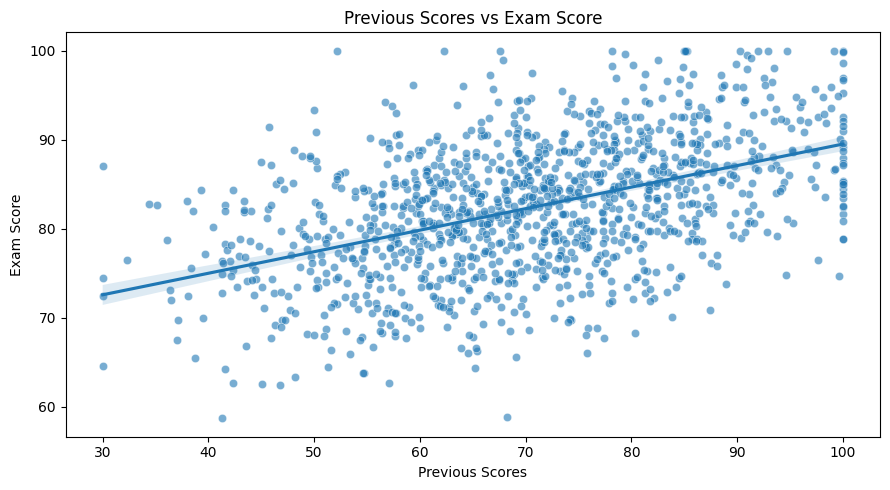

In [13]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Previous Scores", y="Exam Score", alpha=0.6)
sns.regplot(data=df, x="Previous Scores", y="Exam Score", scatter=False)
plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

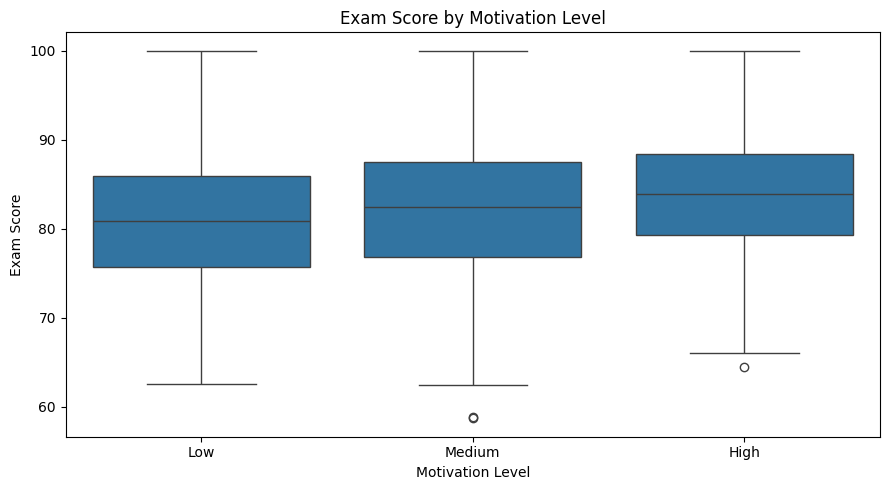

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Motivation Level", y="Exam Score")
plt.title("Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

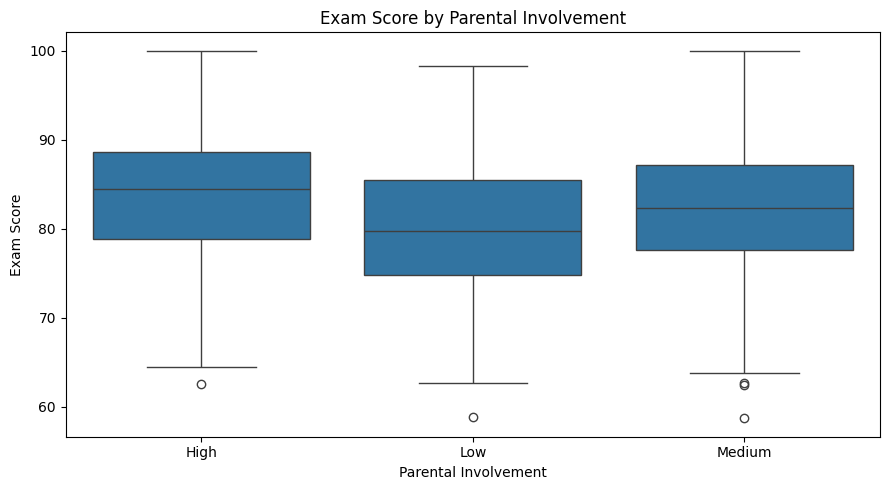

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Parental Involvement", y="Exam Score")
plt.title("Exam Score by Parental Involvement")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

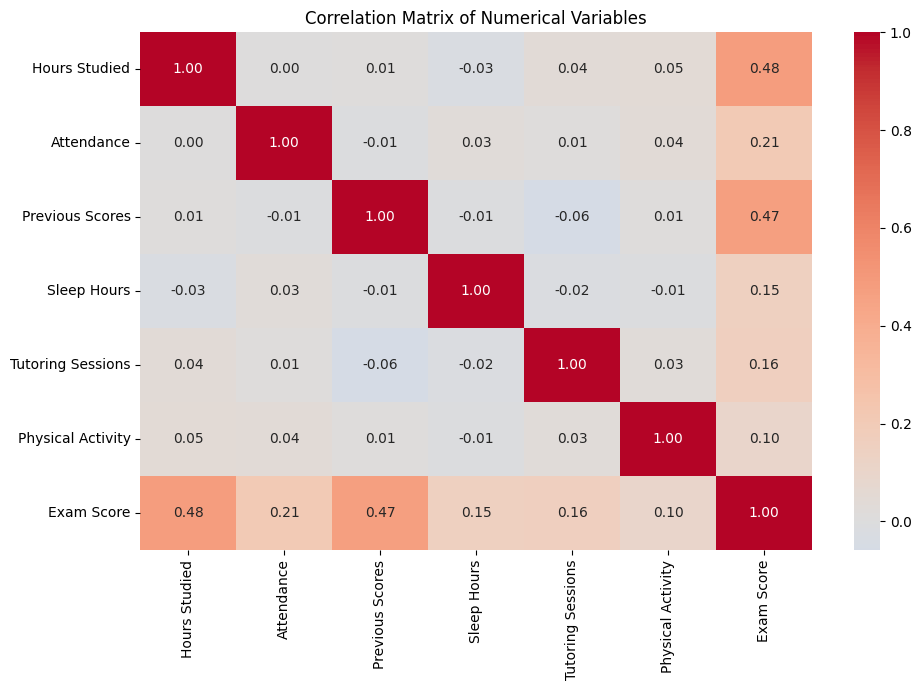

In [16]:
numeric_for_corr = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_for_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [17]:
corr_with_target = (
    df.select_dtypes(include=np.number)
      .corr()["Exam Score"]
      .drop("Exam Score")
      .sort_values(key=abs, ascending=False)
)

corr_with_target.to_frame("Correlation with Exam Score")

,Correlation with Exam Score
Hours Studied,0.478417
Previous Scores,0.469309
Attendance,0.205577
Tutoring Sessions,0.161373
Sleep Hours,0.152216
Physical Activity,0.097147


## 6. EDA Findings

The visualizations above are used to identify patterns rather than assume relationships in advance.

Typical questions to consider:
- Does exam score tend to increase as study hours increase?
- Is attendance positively associated with performance?
- Are previous scores strongly related to final performance?
- Do categorical factors such as motivation or parental involvement show differences in score distributions?
- Are there any unusual observations or potential outliers?

The exact conclusions should be based on the plots and correlation values generated by the dataset.

## 7. Preparing Data for Machine Learning

The target variable is:

**y = Exam Score**

All remaining variables are candidate predictors.

Numerical variables are imputed with the median and standardized. Categorical variables are imputed with the most frequent category and one-hot encoded.

A `ColumnTransformer` and `Pipeline` are used so preprocessing is learned only from the training data. This helps prevent information leakage from the test set into model training.

In [18]:
X = df.drop(columns=["Exam Score"])
y = df["Exam Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Training rows: 960
Testing rows: 240
Numerical features: ['Hours Studied', 'Attendance', 'Previous Scores', 'Sleep Hours', 'Tutoring Sessions', 'Physical Activity']
Categorical features: ['Parental Involvement', 'Access to Resources', 'Motivation Level', 'Internet Access', 'School Type', 'Parental Education Level', 'Distance from Home', 'Gender']


## 8. Model 1 — Linear Regression

In [19]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print(f"MAE:  {linear_mae:.3f}")
print(f"RMSE: {linear_rmse:.3f}")
print(f"R²:   {linear_r2:.3f}")

MAE:  3.537
RMSE: 4.431
R²:   0.663


## 9. Model 2 — Decision Tree Regressor

In [20]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ))
])

tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

print(f"MAE:  {tree_mae:.3f}")
print(f"RMSE: {tree_rmse:.3f}")
print(f"R²:   {tree_r2:.3f}")

MAE:  5.554
RMSE: 6.938
R²:   0.174


## 10. Model 3 — Random Forest Regressor

In [21]:
forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print(f"MAE:  {forest_mae:.3f}")
print(f"RMSE: {forest_rmse:.3f}")
print(f"R²:   {forest_r2:.3f}")

MAE:  4.281
RMSE: 5.327
R²:   0.513


## 11. Model Comparison

In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R²": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

results = results.sort_values("RMSE").reset_index(drop=True)
results.round(3)

,Model,MAE,RMSE,R²
0,Linear Regression,3.537,4.431,0.663
1,Random Forest,4.281,5.327,0.513
2,Decision Tree,5.554,6.938,0.174


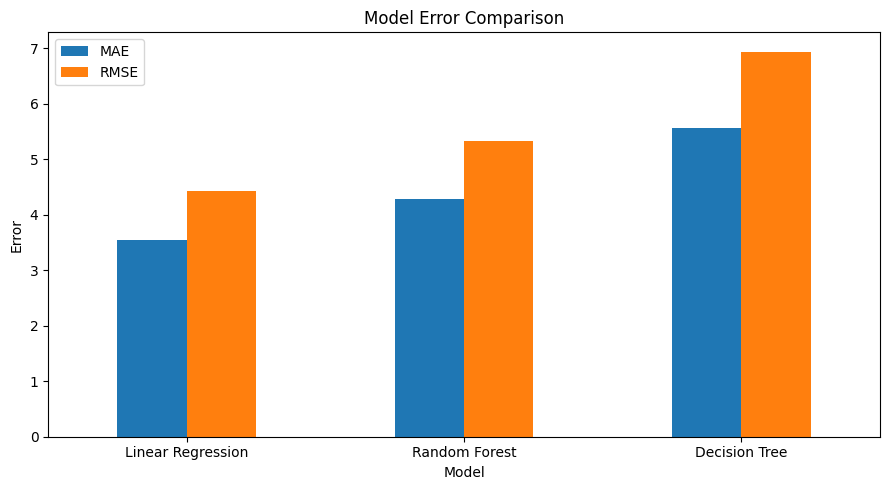

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
results_plot = results.set_index("Model")[["MAE", "RMSE"]]
results_plot.plot(kind="bar", ax=ax)
ax.set_title("Model Error Comparison")
ax.set_ylabel("Error")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

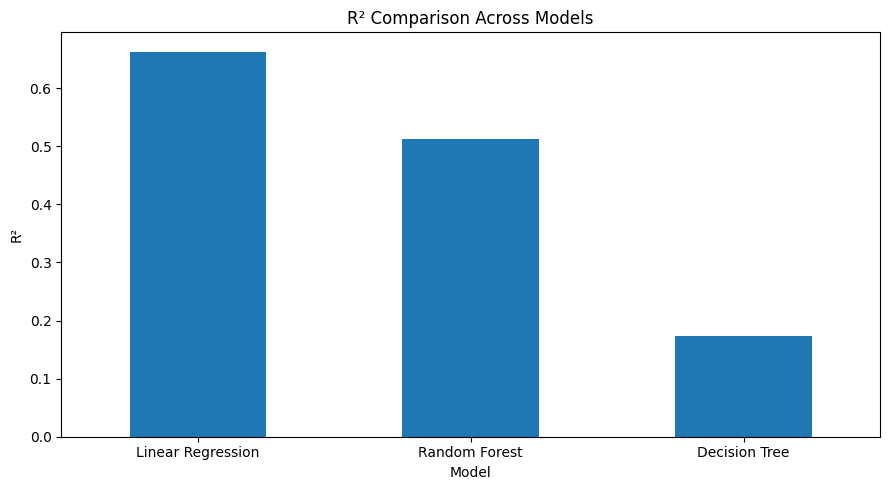

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
results.set_index("Model")["R²"].plot(kind="bar", ax=ax)
ax.set_title("R² Comparison Across Models")
ax.set_ylabel("R²")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Evaluation Metrics

**MAE (Mean Absolute Error)** represents the average absolute difference between actual and predicted scores. Lower is better.

**RMSE (Root Mean Squared Error)** gives greater weight to larger errors. Lower is better.

**R² (Coefficient of Determination)** measures the proportion of variation in the target explained by the model. Higher is generally better.

For this project, model selection considers all three metrics rather than relying on a single score.

## 12. Actual vs Predicted Performance

In [25]:
best_model_name = results.iloc[0]["Model"]

prediction_map = {
    "Linear Regression": linear_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions
}

best_predictions = prediction_map[best_model_name]

comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": best_predictions
})

comparison["Absolute Error"] = (
    comparison["Actual Score"] - comparison["Predicted Score"]
).abs()

comparison.head(15).round(2)

,Actual Score,Predicted Score,Absolute Error
0,83.4,87.11,3.71
1,77.9,84.82,6.92
2,81.6,80.59,1.01
3,87.9,83.69,4.21
4,75.4,74.22,1.18
5,88.4,84.11,4.29
6,83.1,84.87,1.77
7,86.6,82.78,3.82
8,73.3,73.31,0.01
9,85.9,85.44,0.46


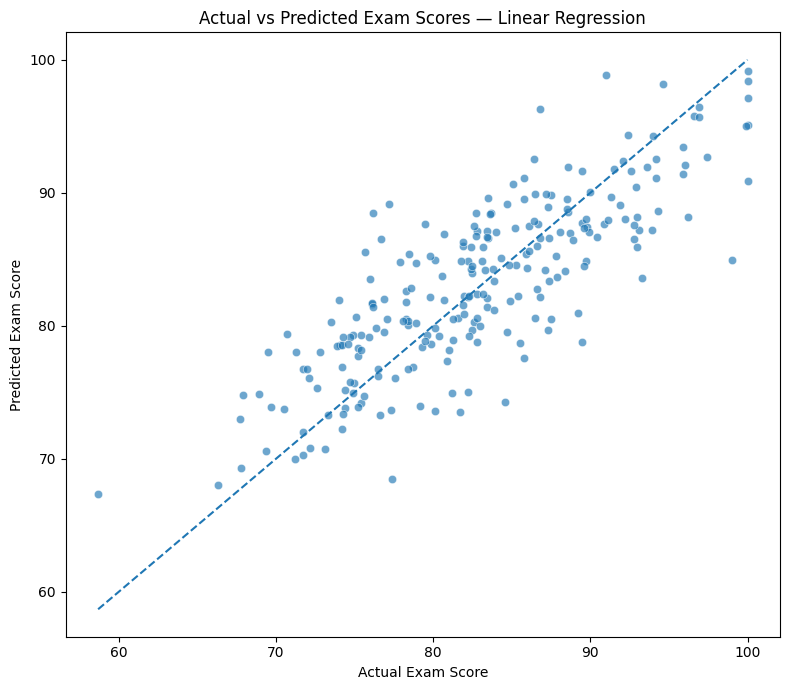

In [26]:
plt.figure(figsize=(8, 7))
sns.scatterplot(
    x=comparison["Actual Score"],
    y=comparison["Predicted Score"],
    alpha=0.65
)

min_value = min(comparison["Actual Score"].min(), comparison["Predicted Score"].min())
max_value = max(comparison["Actual Score"].max(), comparison["Predicted Score"].max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title(f"Actual vs Predicted Exam Scores — {best_model_name}")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.tight_layout()
plt.show()

## 13. Feature Importance

In [27]:
# Feature importance is available for tree-based models.
# We use the fitted Random Forest pipeline because it can provide interpretable
# importance values after one-hot encoding.

forest_preprocessor = forest_model.named_steps["preprocessor"]
forest_estimator = forest_model.named_steps["model"]

feature_names = forest_preprocessor.get_feature_names_out()
importances = forest_estimator.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,num__Hours Studied,0.316406
1,num__Previous Scores,0.313873
2,num__Attendance,0.085868
3,num__Sleep Hours,0.070105
4,num__Physical Activity,0.042392
5,num__Tutoring Sessions,0.030049
6,cat__Parental Involvement_High,0.014277
7,cat__Access to Resources_High,0.012750
8,cat__Motivation Level_Low,0.011718
9,cat__Parental Involvement_Low,0.011190


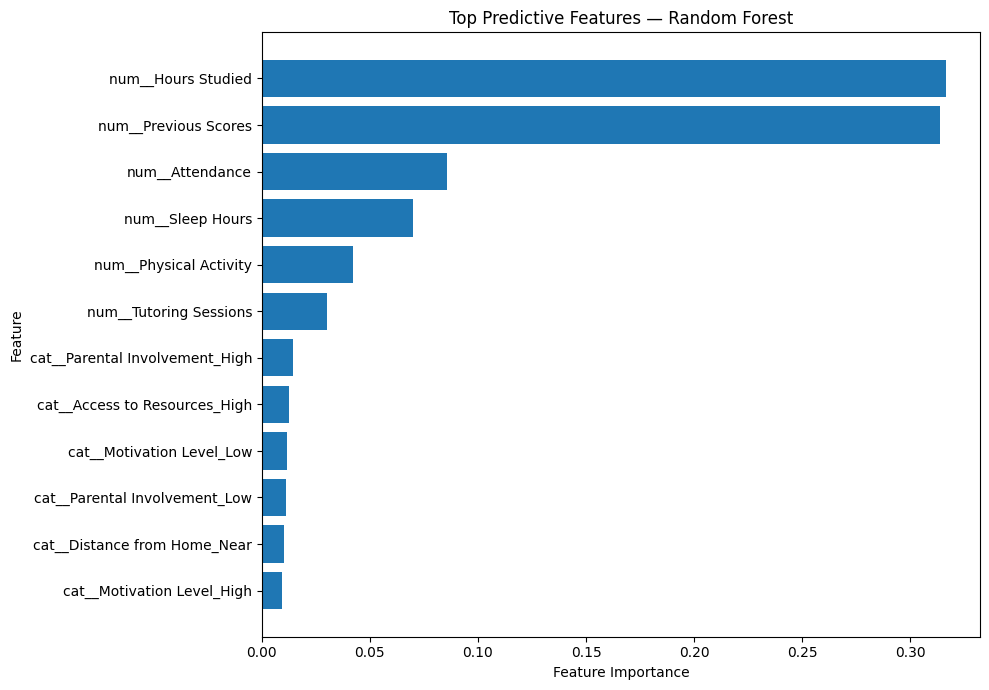

In [28]:
top_features = feature_importance.head(12).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top Predictive Features — Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 14. Predicting a New Student's Score

The trained pipeline can accept a new student record in the same feature format as the original dataset.

The example below automatically creates a sample student using the most common categorical values and median numerical values, then modifies several values to represent a realistic observation.

This is an example prediction, not a guaranteed outcome. Machine learning predictions are estimates based on patterns learned from historical data.

In [29]:
# Build a realistic example student from the training data
new_student = {}

for col in numeric_features:
    new_student[col] = float(X_train[col].median())

for col in categorical_features:
    new_student[col] = X_train[col].mode()[0]

# Modify selected variables when they exist
if "Hours Studied" in new_student:
    new_student["Hours Studied"] = 7

if "Attendance" in new_student:
    new_student["Attendance"] = 90

if "Previous Scores" in new_student:
    new_student["Previous Scores"] = 82

if "Sleep Hours" in new_student:
    new_student["Sleep Hours"] = 7

if "Tutoring Sessions" in new_student:
    new_student["Tutoring Sessions"] = 3

new_student_df = pd.DataFrame([new_student])

predicted_score = best_predictions[0]  # overwritten below
predicted_score = (
    linear_model.predict(new_student_df)[0]
    if best_model_name == "Linear Regression"
    else tree_model.predict(new_student_df)[0]
    if best_model_name == "Decision Tree"
    else forest_model.predict(new_student_df)[0]
)

print("Example student:")
display(new_student_df)
print(f"\nPredicted Exam Score: {predicted_score:.2f}")

Example student:


,Hours Studied,Attendance,Previous Scores,Sleep Hours,Tutoring Sessions,Physical Activity,Parental Involvement,Access to Resources,Motivation Level,Internet Access,School Type,Parental Education Level,Distance from Home,Gender
0,7,90,82,7,3,2.901213,Medium,Medium,Medium,Yes,Public,College,Moderate,Female



Predicted Exam Score: 91.82


## 15. Final Results

The final model is selected based on the comparison of MAE, RMSE, and R² on the held-out test set.

### What the results mean

- A lower MAE indicates smaller average prediction errors.
- A lower RMSE indicates fewer large prediction errors.
- A higher R² indicates that the model explains more variation in exam scores.

The numerical values below are generated directly from the executed notebook, so the conclusions remain tied to the actual dataset used.

In [30]:
best_row = results.iloc[0]

print("FINAL MODEL")
print("-" * 40)
print(f"Selected model: {best_row['Model']}")
print(f"MAE:  {best_row['MAE']:.3f}")
print(f"RMSE: {best_row['RMSE']:.3f}")
print(f"R²:   {best_row['R²']:.3f}")

FINAL MODEL
----------------------------------------
Selected model: Linear Regression
MAE:  3.537
RMSE: 4.431
R²:   0.663


## 16. Key Findings

Based on the completed analysis, the following should be reviewed before final submission:

1. **Study behaviour:** Examine whether study hours show a positive relationship with exam performance.
2. **Attendance:** Evaluate whether students with higher attendance tend to achieve higher scores.
3. **Previous performance:** Determine whether previous scores are among the strongest numerical predictors.
4. **Lifestyle and academic factors:** Compare score distributions across variables such as motivation, parental involvement, and access to resources.
5. **Model performance:** Compare the regression models using MAE, RMSE, and R².
6. **Feature importance:** Use the Random Forest feature-importance chart to identify variables that contributed most strongly to predictions.

> The final written interpretation should use the actual values and patterns generated above rather than assuming that every factor has a causal effect on performance.

## 17. Limitations

This project has several limitations:

- A predictive relationship does not imply causation.
- The dataset may not represent students from every school, region, or demographic group.
- Important variables may be absent from the dataset.
- Model performance depends on the quality and representativeness of the available data.
- Feature importance indicates predictive usefulness within the model; it should not automatically be interpreted as a causal effect.
- A single train/test split provides only one estimate of generalization performance. Cross-validation could provide a more robust estimate.

## 18. Future Improvements

Potential improvements include:

- Use k-fold cross-validation for more reliable model evaluation.
- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Test additional regression algorithms such as Gradient Boosting or XGBoost.
- Investigate outliers and nonlinear relationships in greater detail.
- Add explainability techniques such as permutation importance or SHAP.
- Validate the model on an independent external dataset.
- Build a small web application where users can enter student characteristics and receive a prediction.

## 19. Conclusion

This project followed an end-to-end Data Science workflow:

**Data Collection → Data Cleaning → EDA → Feature Preparation → Train/Test Split → Model Training → Evaluation → Model Comparison → Interpretation → Prediction**

The analysis demonstrates how Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn can be combined to investigate a real-world problem and build predictive models.

The most important takeaway is that machine learning is not only about training an algorithm. A reliable project also requires understanding the data, preventing leakage, selecting appropriate evaluation metrics, comparing models, interpreting results, and clearly communicating limitations.

## 20. Technologies Used

- **Python**
- **Pandas**
- **NumPy**
- **Matplotlib**
- **Seaborn**
- **Scikit-learn**
- **Google Colab / Jupyter Notebook**
- **GitHub**

### Project Type
End-to-end Data Science and supervised Machine Learning regression project.

## 21. Portfolio Summary

**Project:** Student Performance Prediction & Analysis

**Objective:** Analyze student-performance factors and predict final exam scores using machine learning.

**Techniques:** Data cleaning, exploratory data analysis, correlation analysis, categorical encoding, feature preprocessing, Linear Regression, Decision Tree Regression, Random Forest Regression, model comparison, and feature importance.

**Evaluation:** MAE, RMSE, and R² on an unseen test set.

**Outcome:** A reproducible end-to-end Data Science workflow suitable for a beginner portfolio and internship submission.